In [64]:
import numpy as np
import matplotlib.pyplot as plt
from aotools.turbulence import r0_to_cn2,cn2_to_r0

# Butterley code for theoretical slope weighting functions (integral method):

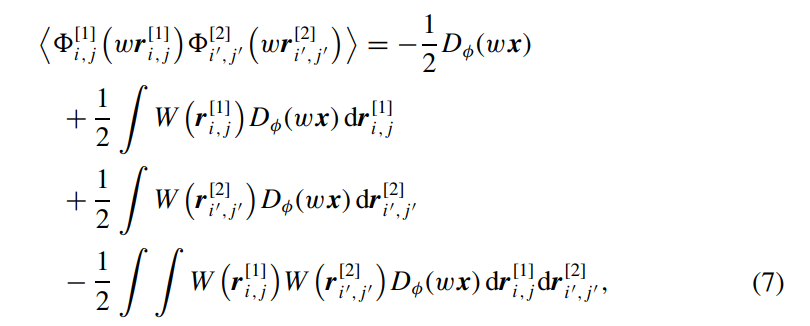

cite: T. Butterley, R. W. Wilson, and M. Sarazin, “Determination of the profile of atmospheric optical turbulence strength from SLODAR data,” _Monthly Notices of the Royal Astronomical Society_, vol. 369, no. 2, pp. 835–845, May 2006, doi: 10.1111/j.1365-2966.2006.10337.x.

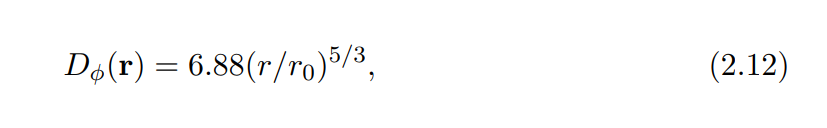

cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].

Code obtained courtesy of Butterley for theoretical SLODAR autocovariance, translated from C to Python and modified to output covariance only for a single star.

---

**The result is used as ground truth for the Fourier-based tests.**


In [2]:
import numpy as np

def kol_strucfunc(r, r0=1.0):
    # 6.88*(r/r0)^(5/3)
    return 6.88 * (r / r0) ** (5.0 / 3.0)

def slopecov_kol(nsubx: int, 
                 d: float,
                 lam: float = 500e-9,
                 scalingFactor: float =1,
                 nsamp: int =  8):
    """
    slodar_slopecovKol2(nsubx, nsamp, d) wrapper for Python.
    return cov con shape: (2, nn, nn) where nn = 2*nsubx-1 cov matrix for x-slope and y-slope .

    cov[0, di, dj] -> cov_xx  
    cov[1, di, dj] -> cov_yy 
    """

    nn = 2 * nsubx - 1
    cov = np.zeros((2, nn, nn))

    # from C: sub-aperture coords in [-0.5,0.5)  offset of 0.5/nsamp
    rxy = (np.arange(nsamp) - (nsamp / 2) + 0.5) / nsamp
    tilt = 2.0 * np.sqrt(3.0) * rxy  # tilt[i] = 2*sqrt(3)*rxy[i]

    # from C (hard-wired lam=500nm and r0=d)
    scaling = scalingFactor * (206265.0 ** 2) * 3.0 * (lam / (np.pi * d)) ** 2
    n2 = nsamp * nsamp
    n4 = n2 * n2
 
    
    # Integral method for slopes weighting functions

    for i in range(nn):
        for j in range(nn):
            ra_intgrl = np.zeros((nsamp, nsamp))
            rb_intgrl = np.zeros((nsamp, nsamp))
            D_phi = np.zeros((nsamp, nsamp, nsamp, nsamp))

            dbl_intgrl = 0.0

            # 1) build D_phi and acumulation of partial integrals (ra, rb) + total integration 
            for ia in range(nsamp):
                for ja in range(nsamp):
                    for ib in range(nsamp):
                        for jb in range(nsamp):
                            x = (i - nsubx + 1) - rxy[ia] + rxy[ib]
                            y = (j - nsubx + 1) - rxy[ja] + rxy[jb]
                            r = np.sqrt(x * x + y * y)
                            val = kol_strucfunc(r, r0=1.0)
                            D_phi[ia, ja, ib, jb] = val

                            ra_intgrl[ib, jb] += val
                            rb_intgrl[ia, ja] += val
                            dbl_intgrl += val

            # 2) build phiphi and acumulation of tilt covariance on x and y
            xtiltcov = 0.0
            ytiltcov = 0.0
            mean_dbl = dbl_intgrl / (nsamp ** 4)

            for ia in range(nsamp):
                for ja in range(nsamp):
                    for ib in range(nsamp):
                        for jb in range(nsamp):

                            # phiphi = 0.5*((ra+rb)/n2) - 0.5*D_phi - 0.5*(dbl/nsamp^4)
                            phiphi = 0.5 * ((ra_intgrl[ib, jb] + rb_intgrl[ia, ja]) / n2)
                            phiphi -= 0.5 * D_phi[ia, ja, ib, jb]
                            phiphi -= 0.5 * mean_dbl

                            ytiltcov += phiphi * tilt[ia] * tilt[ib] * scaling
                            xtiltcov += phiphi * tilt[ja] * tilt[jb] * scaling

            cov[0, i, j] =  xtiltcov / n4   # X-slope cov
            cov[1, i, j] =  ytiltcov / n4   # y-slope cov

    return cov



# Function test:


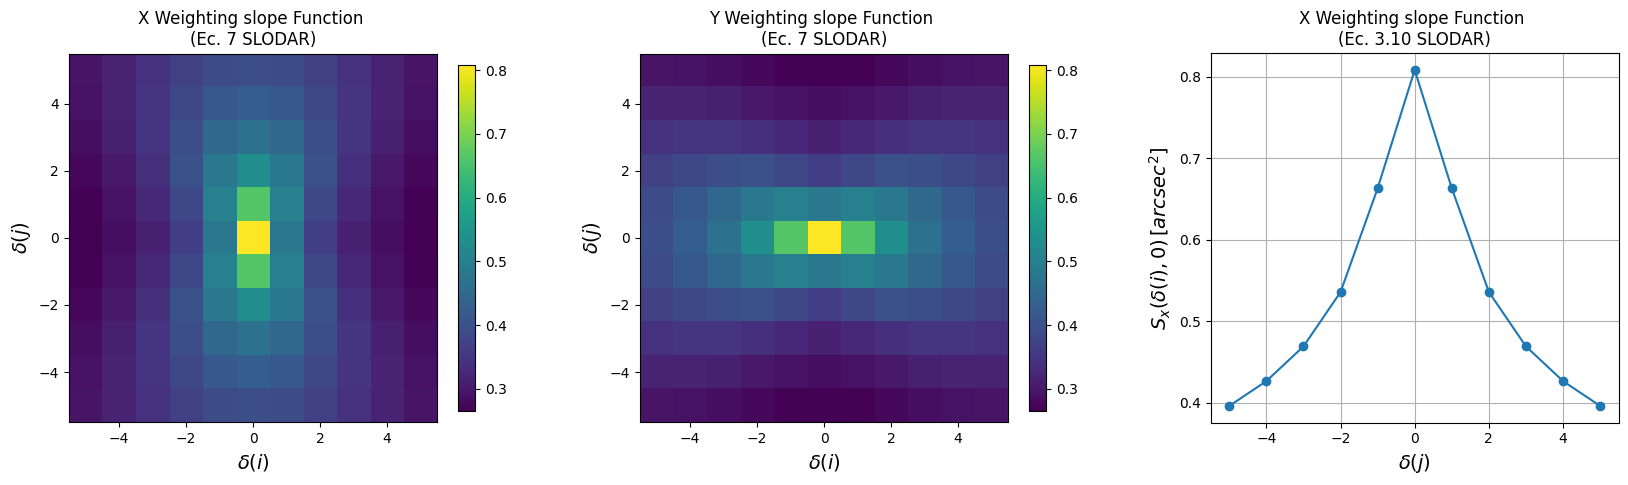

In [3]:
import matplotlib.pylab as plt
# --- Example params ---

d = 0.047   # sub-aperture size
nsubx = 6   # sub-apertures 
samp = 8    # sampling

tcov = slopecov_kol(nsubx, d) #<-- function call

GRID_SIZE = 2 * nsubx - 1
BEAM = 1


# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(tcov[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('X Weighting slope Function \n(Ec. 7 SLODAR)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(tcov[1,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('Y Weighting slope Function \n(Ec. 7 SLODAR)')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im2, ax=ax2, shrink=0.75, fraction=0.046)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),tcov[0,:,5], "-o")
ax3.set_title('X Weighting slope Function \n(Ec. 3.10 SLODAR)')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("on")

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])

# Z-tilt filter based on Ryan thesis:

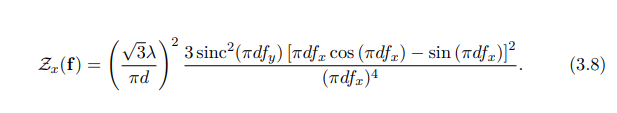

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].
- ref: eq 3.8 Z-tilt filter


In [4]:
def calculate_Zx_spectral_filter(fx: np.ndarray, fy: np.ndarray, wavelength: float, d: float):
    """
    spectral filter Z_x(f) (Ec. 3.8).
    
    Args:
        fx (ndarray)       : spatial frecuency in X.
        fy (ndarray)       : spatial frecuency in Y.
        d (float)          : sub-aperture size.
        
    Returns:

        Zx(F) (ndarray): spatial filter.
    """

    scalingFactor = ((np.sqrt(3) * wavelength) / (np.pi * d)) ** 2
    y_term = 3 * (np.sinc(d * fy)) ** 2

    # [u*cos(u) - sin(u)]^2 / u^4, where u = pi*d*fx
    u = np.pi * d * fx
    u2 = u*u
    u4 = u2*u2 # @dev_note: I found this way of obtaining u^4 curious but interesting.
    
    # init X term with zeros
    x_term = np.zeros_like(u)
    mask = np.abs(u) > 0 #<-- mask preventing x/0 cases
    
    # numerator: [u cos(u) - sin(u)]^2
    numerator = ( u[mask] * np.cos(u[mask]) - np.sin(u[mask])) ** 2
    
    # [u cos(u) - sin(u)]^2 / u^4
    x_term[mask] = numerator / u4[mask]
    
    Zx =  y_term * x_term * scalingFactor 
    return Zx



# Multy-layer Kolmogorov PSD from equation 2.11 :

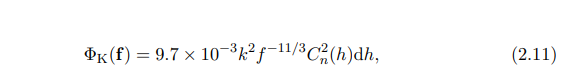

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].
- ref: eq 2.11 Kolmogorov PSD

---


In [5]:

import numpy as np

def Kolmogorov_PSD(f: np.ndarray, wavelength: float, glob: bool, r0Cn2=1.0):
    """
        spectral filter Z_x(f) (Ec. 3.8).
    
        Args:
            f (ndarray)       : spatial frecuency in X.
            r0 float          : strength of the turbulent in the layer  
            glob (Bool)       : if you want to use a Phi_K with a global r0 or not
            
        Returns:

            Phi_K(F) (ndarray): kolmogorov_PSD.
    """

    k = 2 * np.pi / wavelength
    k2 = k*k

    Phi_K = np.zeros_like(f)

    # x/0 prevention
    mask_f = f > 0 

    if glob:
        # kolmogorov PSD Integrated r0 
        # r0 = cn2_to_r0(r0,lamda=wavelength)
        Phi_K = 0.023 *(r0Cn2 ** (-5/3)) * (f ** (-11/3)) 
       
    else:
        Cn2_dh = r0Cn2           # asumes a layer with cn2 = 1

        #Kolmogorov PSD eq (2.11): layer aproach
        Phi_K[mask_f] = 9.7e-3 * k2 * (f[mask_f] ** (-11/3)) * Cn2_dh

    # piston remove
    Phi_K[0,0] = 0

    return Phi_K



# Fourier filter method for Slopes Weigthing function:

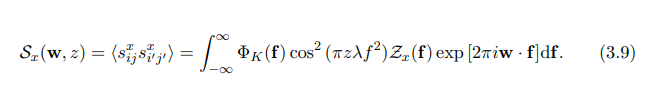

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].
- ref: eq 3.9 Fourier method filter

---


In [6]:
def weighting_function(d: float,
                       dx: float,
                       nsubx: int,
                       samp: int,
                       cn2r0: float = 1.,
                       wavelength: float =500e-9,
                       h:float =0.,
                       scalingFactor: float = 1.,
                       glob: bool = False):

    """
    calculate weighting function (cov) for SHIMM.
    
    Args:

        dx(float)           : steps in phychic aperture [m]
        h (float)           : layer altitude    [m].
        d (float)           : sub-aperture size [m].
        samp(int)           : frequency oversampling
        glob (Bool)         : if you want to use a Phi_K with a global r0 or not
        nsubx (int)         : grid size.
        cn2r0(float)        : value of r0 or cn2 in K_PSD depends on glob
        sclaingFactor(float): if you want to get the result in rad2 or arcsec2

    Returns:
    return  W_z (ndarray): [2,N,N]. where N = 2*nsubx-1 

    cov matrix for x-slope and y-slope .

    cov[0, di, dj] -> cov_xx  
    cov[1, di, dj] -> cov_yy 

    """
    
    # C: matriz espacial (p.ej. covarianza) tamaño N0xN0
    Nfft = max(256, samp) 

    # 1. spatio-frequency domain (fx, fy)
    # freq = np.fft.fftfreq(Nfft, d=dx).astype("float64")    #<-- spatio-frequency vector based on sub-aperture grid size [ cycles / (m)]
    # freq[0] = freq[1]/8
    freq = ((np.arange(Nfft) - (Nfft / 2) + 0.5) / (Nfft * dx)) 
    freq = np.fft.fftshift(freq)

    fx, fy = np.meshgrid(freq, freq) 


    # spatio-frequency magnitude 
    f = np.hypot(fx,fy)   # f = ||f||
    f2 = f*f

    
    # 3. Shack-Hartmann aperture filter (Ec. 3.8)
    A_fx = calculate_Zx_spectral_filter(fx, fy, wavelength, d)
    A_fy = calculate_Zx_spectral_filter(fy ,fx ,wavelength, d)
    

    # 4. propagation ( sinusoidal term in Ec. 3.9) fresnel phase param
    Fresnel_term = np.cos(np.pi * wavelength * h * f2)**2

    #5. Kolmogorov PSD obtain (Ec. 2.11)
    Phi_K = Kolmogorov_PSD(f,wavelength,glob,cn2r0)

    # 6. Filter applied
    spectral_densityX =  Phi_K * Fresnel_term * A_fx  
    spectral_densityY =  Phi_K * Fresnel_term * A_fy 
    spectral_densityX[0,0] = 0.0
    spectral_densityY[0,0] = 0.0

    # 7. ifft
    # df = (freq[1] - freq[0])/ np.pi
    # fft_integral_scale = (Nfft**2) * (df**2)
    covariance_mapX = np.fft.ifft2(spectral_densityX) *  1/(dx*dx ) #convertion to a continuous spectrum 
    covariance_mapY = np.fft.ifft2(spectral_densityY) *  1/(dx*dx)
    
    
    covariance_mapX = np.fft.fftshift(covariance_mapX) 
    covariance_mapY = np.fft.fftshift(covariance_mapY) 

    mid = int(Nfft/2)
    stride = int(round(d / dx))   # si dx=d/2 -> stride=2
    k = np.arange(-(nsubx-1), nsubx)  # [-5..+5] para nsubx=6
    idx = mid + stride * k

    W_zX = np.real(covariance_mapX[np.ix_(idx,idx)]) * scalingFactor  # X slope on [Rad^2] -> [arcsec^2]
    W_zY = np.real(covariance_mapY[np.ix_(idx,idx)]) * scalingFactor  # Y slope on [Rad^2] -> [arcsec^2]

    return np.array([W_zX,W_zY])


# Example:

---


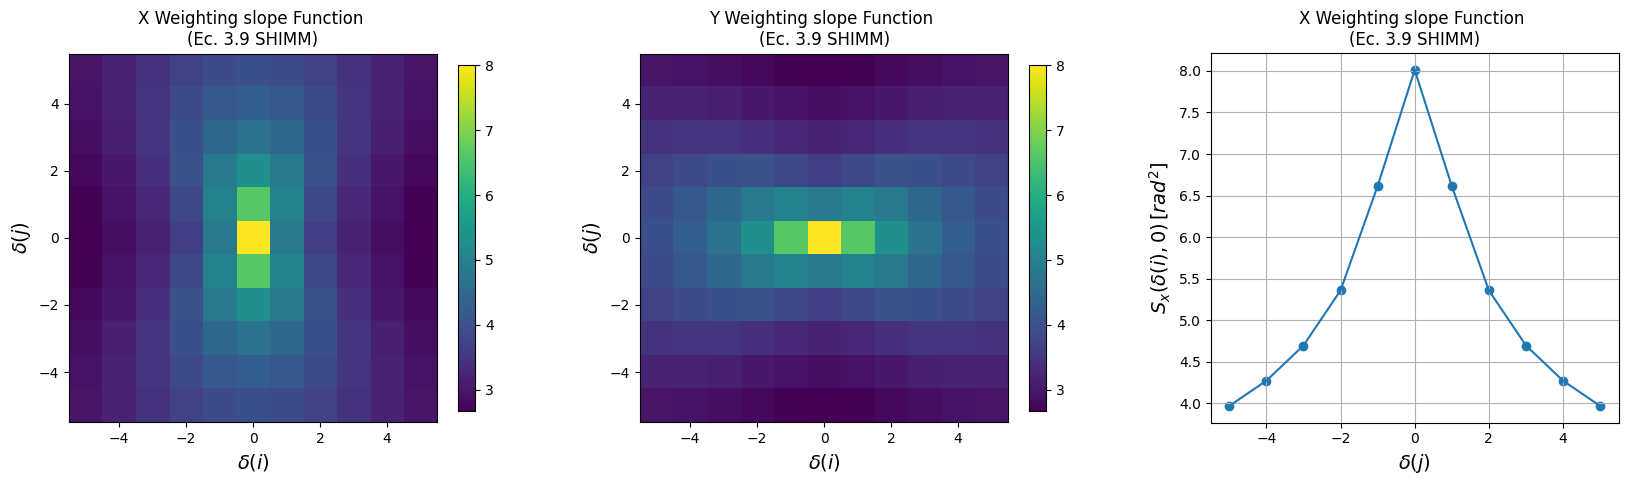

In [8]:
import matplotlib.pyplot as plt
# --- Example params ---

d = 0.047   # sub-aperture size
nsubx = 6   # sub-apertures 
dx = d/2
samp = 10
N = 2**samp #<-- 1024


tcov = weighting_function(d,dx, nsubx,N) + 1

GRID_SIZE = 2 * nsubx - 1 
BEAM = 1

# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(tcov[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('X Weighting slope Function \n(Ec. 3.9 SHIMM)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(tcov[1,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('Y Weighting slope Function \n(Ec. 3.9 SHIMM)')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im2, ax=ax2, shrink=0.75, fraction=0.046)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),tcov[0,:,5],)
ax3.scatter(np.arange(-5, 6),tcov[0,:,5],)
ax3.set_title('X Weighting slope Function \n(Ec. 3.9 SHIMM)')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("on")

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])

# G-tilt and Scintillation functions:

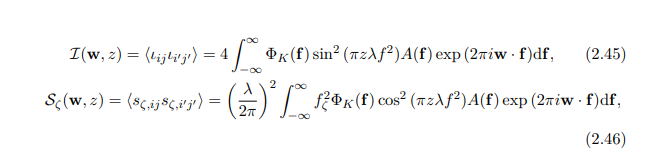

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].

- ref: eq 2.45 Slopes Weighting function G-tilt
- ref: eq 2.46 scintillation Weighting function


In [9]:
import numpy as np
def slope_weighting_function(d: float,
                             dx: float,
                             nsubx: int,
                             samp: int,
                             cn2r0: float = 1.,
                             wavelength: float =500e-9,
                             h:float =0.,
                             scalingFactor: float = 1.,
                             glob: bool = False):

    """
    calculate weighting function (cov) for SHIMM.
    
    Args:

        dx(float)           : steps in phychic aperture [m]
        h (float)           : layer altitude    [m].
        d (float)           : sub-aperture size [m].
        samp(int)           : frequency oversampling
        glob (Bool)         : if you want to use a Phi_K with a global r0 or not
        nsubx (int)         : grid size.
        cn2r0(float)        : value of r0 or cn2 in K_PSD depends on glob
        sclaingFactor(float): if you want to get the result in rad2 or arcsec2

    Returns:
    return  W_z (ndarray): [2,N,N]. where N = 2*nsubx-1 

    cov matrix for x-slope and y-slope .

    cov[0, di, dj] -> cov_xx  
    cov[1, di, dj] -> cov_yy 

    """
    # C: matriz espacial (p.ej. covarianza) tamaño N0xN0
    Nfft = max(256, samp) 

    # 1. spatio-frequency domain (fx, fy)
    freq = np.fft.fftfreq(Nfft, d=dx)   #<-- spatio-frequency vector based on sub-aperture grid size [cycles/m]

    # freq[0] = freq[1]/2  #<-- how to manage this
    fx, fy = np.meshgrid(freq, freq) 

    # spatio-frequency magnitude 
    f = np.hypot(fx,fy)   # f = ||f||
    f2 = f*f

    # ---------------------------------------------------------
    
    # 3. Shack-Hartmann Aperture filter (Ec. 2.44)
    A_f =  (np.sinc(d * fx)**2) * (np.sinc(d * fy)**2)
    

    # 4. propagation ( sinusoidal term in Ec. 2.42/2.45) fresnel phase param
    Fresnel_term = np.cos(np.pi * wavelength * h * f2)**2

    #5. Kolmogorov PSD 
    Phi_K = Kolmogorov_PSD(f,wavelength,glob,cn2r0)
    scaling = wavelength**2

    spectral_densityX = fx * fx * Phi_K * Fresnel_term * A_f * scaling 
    spectral_densityY = fy * fy * Phi_K * Fresnel_term * A_f * scaling

    df = freq[1] - freq[0]
    fft_integral_scale = (Nfft**2) * (df**2)

    # 6. Numerical solution using IFFT 
    covariance_mapX = np.fft.ifft2(spectral_densityX) * fft_integral_scale
    covariance_mapY = np.fft.ifft2(spectral_densityY) * fft_integral_scale
    
    # fftshift centra la frecuencia cero en el medio de la imagen para visualización
    covariance_mapX = np.fft.fftshift(covariance_mapX) 
    covariance_mapY = np.fft.fftshift(covariance_mapY) 

    mid = int(Nfft/2)
    stride = int(round(d / dx))   # if dx=d/2 -> stride=2
    k = np.arange(-(nsubx-1), nsubx)  # [-5..+5] for nsubx=6
    idx = mid + stride * k

    W_zX = np.real(covariance_mapX[np.ix_(idx,idx)]) * scalingFactor  # X slope on [Rad^2] -> [arcsec^2]
    W_zY = np.real(covariance_mapY[np.ix_(idx,idx)]) * scalingFactor  # Y slope on [Rad^2] -> [arcsec^2]

    return np.array([W_zX,W_zY])




def scintillation_weighting_function(d: float,
                             dx: float,
                             nsubx: int,
                             samp: int,
                             cn2r0: float = 1.,
                             wavelength: float =500e-9,
                             h:float =0.,
                             scalingFactor: float = 1.,
                             glob: bool = False):

    """
    calculate weighting function (cov) for SHIMM.
    
    Args:

        dx(float)           : steps in phychic aperture [m]
        h (float)           : layer altitude    [m].
        d (float)           : sub-aperture size [m].
        samp(int)           : frequency oversampling
        glob (Bool)         : if you want to use a Phi_K with a global r0 or not
        nsubx (int)         : grid size.
        cn2r0(float)        : value of r0 or cn2 in K_PSD depends on glob
        sclaingFactor(float): if you want to get the result in rad2 or arcsec2

    Returns:
    return  W_z (ndarray): [N,N]. where N = 2*nsubx-1 

    cov matrix for Scintillation index .

    cov[di, dj] -> cov_I 

    """
    
    # 1. spatio-frequency domain (fx, fy)
    Nfft = max(256, samp) 

    # 1. spatio-frequency domain (fx, fy)
    freq = np.fft.fftfreq(Nfft, d=dx)   #<-- spatio-frequency vector based on sub-aperture grid size [cycles/m]
    fx, fy = np.meshgrid(freq, freq) 

    # spatio-frequency magnitude 
    f = np.hypot(fx,fy)   # f = ||f||
    f2 = f*f
    
    # ---------------------------------------------------------
    
    # 3. aperture filter Shack-Hartmann (Ec. 2.44)
    A_f =  (np.sinc(d * fx)**2) * (np.sinc(d * fy)**2)
    
    # 4. propagation ( sinusoidal term in Ec. 2.42/2.45) fresnel phase param
    Fresnel_term = np.sin(np.pi * wavelength * h * f2)**2

    #5. Kolmogorov PSD obtain
    Phi_K = Kolmogorov_PSD(f,wavelength,glob,cn2r0)

    spectral_density = Phi_K * Fresnel_term * A_f * 4

    # 6. Numerical solution using IFFT 
    df = freq[1] - freq[0]
    fft_integral_scale = (Nfft**2) * (df**2)

    covariance_map = np.fft.ifft2(spectral_density) * fft_integral_scale
    covariance_map = np.fft.fftshift(covariance_map) 
    
    # fftshift centra la frecuencia cero en el medio de la imagen para visualización

    mid = int(Nfft/2) 
    stride = int(round(d / dx))   # si dx=d/2 -> stride=2
    k = np.arange(-(nsubx-1), nsubx)  # [-5..+5] para nsubx=6
    idx = mid + stride * k

    # W_z = np.real(covariance_map[mid:mid+N0,mid:mid+N0]) * scalingFactor  # Y slope on [Rad^2] -> [arcsec^2]
    W_z = np.real(covariance_map[np.ix_(idx,idx)]) * scalingFactor  

    return W_z





# Example G-tilt:

---


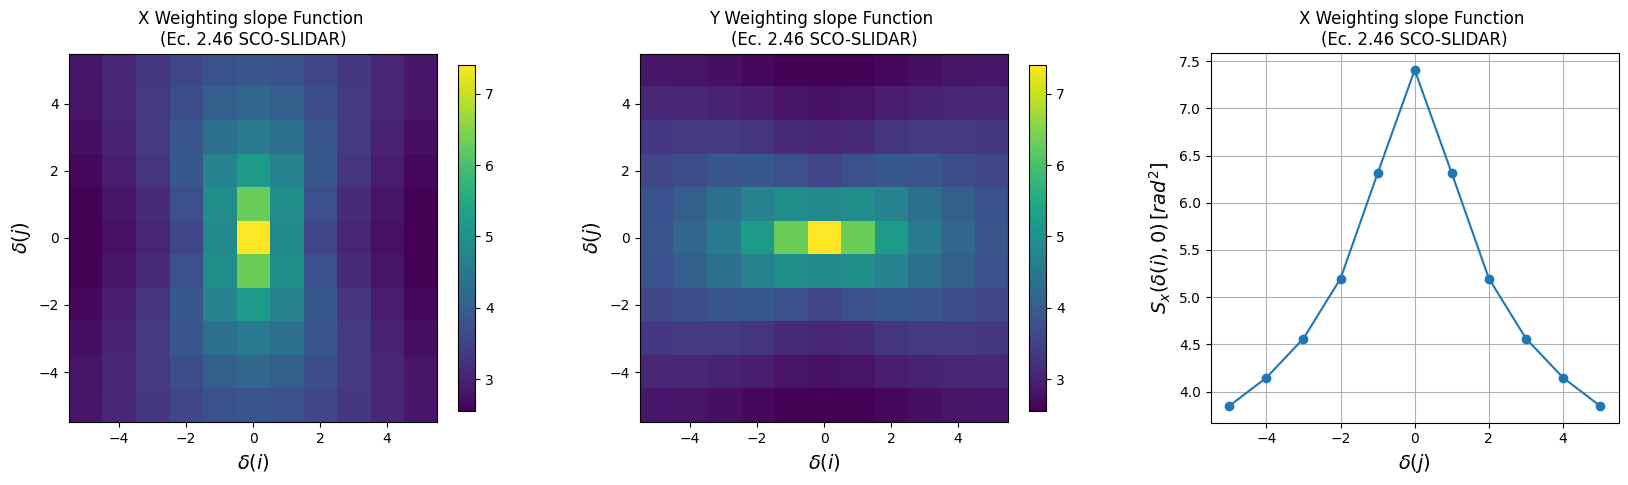

In [12]:
import matplotlib.pyplot as plt
# --- Example params ---

d = 0.047   # sub-aperture size
dx = d/2

nsubx = 6   # sub-apertures 
samp  = 1024

tcov = slope_weighting_function(d, dx,nsubx,samp) + 1 

GRID_SIZE = 2 * nsubx - 1
BEAM = 1

# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(tcov[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('X Weighting slope Function \n(Ec. 2.46 SCO-SLIDAR)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(tcov[1,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('Y Weighting slope Function \n(Ec. 2.46 SCO-SLIDAR)')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im2, ax=ax2, shrink=0.75, fraction=0.046)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),tcov[0,:,5],"-o")
ax3.set_title('X Weighting slope Function \n(Ec. 2.46 SCO-SLIDAR)')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("on")

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])

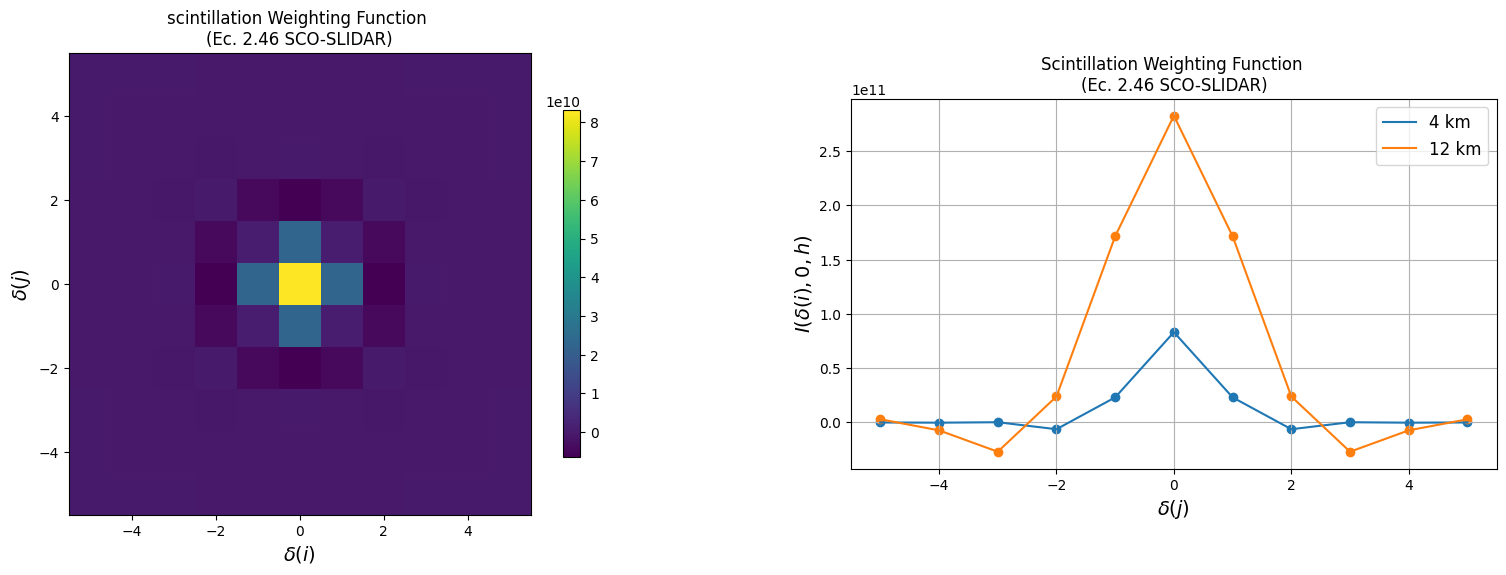

In [75]:
# --- Example params ---

d = 0.047       # sub-aperture size
lamda = 1280e-9 # wavelength
nsubx = 6       # sub-apertures 
samp = 1024     # sampling
cn2 = 1
dx = d/2



tcov1 = scintillation_weighting_function(d, dx, nsubx, samp,scalingFactor=1, h=4e3 , cn2r0=cn2, wavelength=lamda, glob = False)
tcov2 = scintillation_weighting_function(d, dx, nsubx, samp,scalingFactor=1, h=12e3 , cn2r0=cn2, wavelength=lamda, glob = False)

GRID_SIZE = 2 * nsubx - 1
BEAM = 1

# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(tcov1,
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('scintillation Weighting Function \n(Ec. 2.46 SCO-SLIDAR)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(np.arange(-5, 6),tcov1[5,:],label="4 km")
ax2.scatter(np.arange(-5, 6),tcov1[5,:])
ax2.plot(np.arange(-5, 6),tcov2[5,:],label="12 km")
ax2.scatter(np.arange(-5, 6),tcov2[5,:])
ax2.legend(loc="best", fontsize=12)  
ax2.set_title('Scintillation Weighting Function \n(Ec. 2.46 SCO-SLIDAR)')
ax2.set_ylabel(r'$I(\delta(i),0,h)$', fontsize=14)
ax2.set_xlabel(r'$\delta(j)$', fontsize=14)
ax2.grid("on")

pos = ax2.get_position()
ax2.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])

# Tip-tilt Substraction(based on Butterley code):

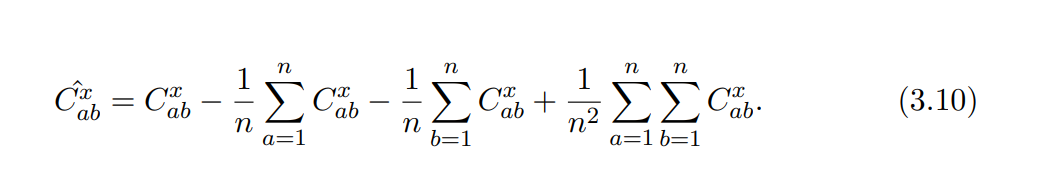

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].
- ref: eq 3.10


In [13]:

import numpy as np

def tip_tilt_sub(cov: np.ndarray, pupil_mask: np.ndarray):
    """
        slodar_refFuncs2D():
      - proyect cov to sub-apertures pairs 
      - tip/tilt subtraction 
      - Re-bined 
    """
    nsubx = pupil_mask.shape[0]
    nn = 2 * nsubx - 1

    # índices de sub-aperturas activas
    active = [(i, j) for j in range(nsubx) for i in range(nsubx) if pupil_mask[j, i] > 0]
    nsubtot = len(active)

    psfs = np.zeros((2, nn, nn), dtype=np.float64)

    # pcov: matriz completa (nsubtot x nsubtot) para x e y intercalados
    pcov = np.zeros((nsubtot, nsubtot, 2), dtype=np.float64)

    # 1) llenar pcov tomando valores desde cov[2*delta] (x) y cov[2*delta+1] (y)
    for a, (i1, j1) in enumerate(active):
        for b, (i2, j2) in enumerate(active):
            di = i2 - i1 + (nsubx - 1)
            dj = j2 - j1 + (nsubx - 1)
            pcov[a, b, 0] = cov[1, di, dj]
            pcov[a, b, 1] = cov[0, di, dj]

    # 2) tip/tilt subtraction: C' = C - rowMean - colMean + globalMean
    row_mean = pcov.mean(axis=1, keepdims=True)   # (nsubtot,1,2)
    col_mean = pcov.mean(axis=0, keepdims=True)   # (1,nsubtot,2)
    glob_mean = pcov.mean(axis=(0, 1), keepdims=True)  # (1,1,2)
    pcov2 = pcov - row_mean - col_mean + glob_mean

    # 3) rebin a separaciones (nn x nn) 
    acc = np.zeros((nn, nn, 2), dtype=np.float64)
    cnt = np.zeros((nn, nn), dtype=np.int64)

    for a, (i1, j1) in enumerate(active):
        for b, (i2, j2) in enumerate(active):
            di = i2 - i1 + (nsubx - 1)
            dj = j2 - j1 + (nsubx - 1)

            acc[di, dj, :] += pcov2[a, b, :]
            cnt[di, dj] += 1

    # cnt>0
    m = cnt > 0
    psfs[0, m] = (acc[m, 0] / cnt[m])
    psfs[1, m] = (acc[m, 1] / cnt[m])

    return psfs

# Example with tip/tilt subsctraction:

---

@Dev_note: While applying these fixes to the notebook, I noticed a small discrepancy between the SLODAR and Z-tilt peak values. One hypothesis is that the difference arises from how low spatial frequencies are handled, specifically at $f=0$. This component appears to contribute the largest amount of energy when applying the Kolmogorov phase. At one point, I considered removing it entirely using a masking approach; however, this did not seem to be the best option, as it introduced a noticeable loss of power in the final result.


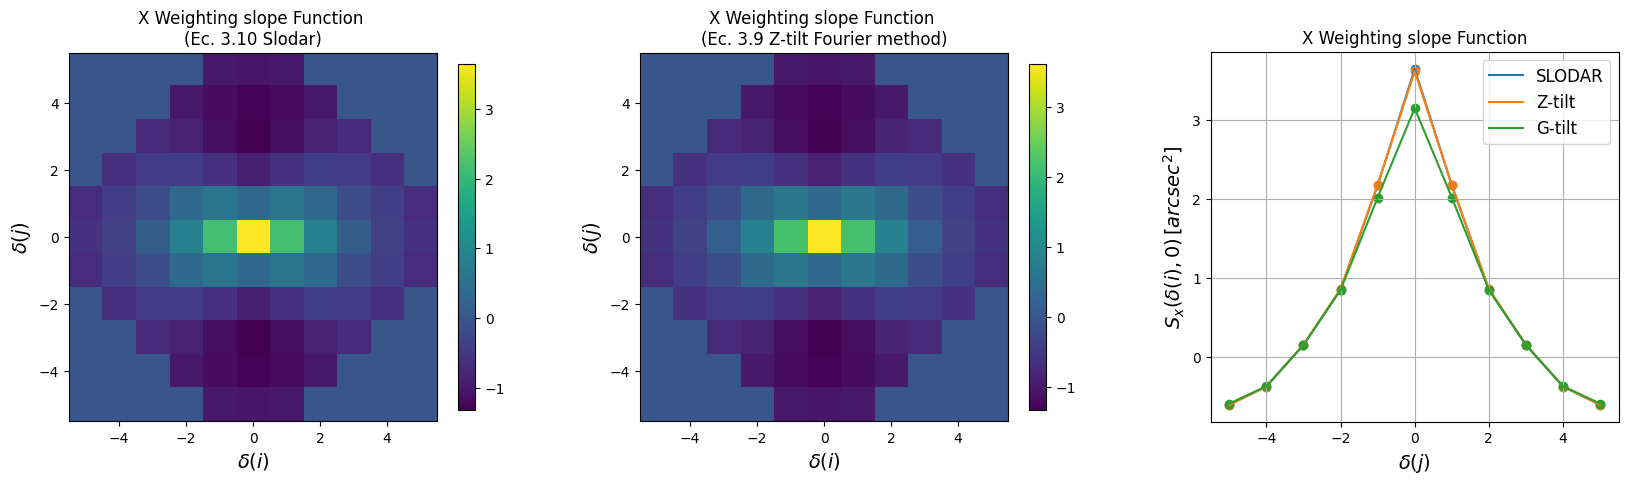

In [14]:
nsubx = 6      # tamaño de la apertura
d = 0.047       # tamaño sub apertura
pupil =  np.array([[0,0,1,1,0,0],
                   [0,1,1,1,1,0],
                   [1,1,0,0,1,1],
                   [1,1,0,0,1,1],
                   [0,1,1,1,1,0],
                   [0,0,1,1,0,0]])


tcov = slopecov_kol(nsubx,d, 500e-9,nsamp=8, scalingFactor=(np.pi*np.pi)) #<-- Rad2
Zcov = weighting_function(d, dx, nsubx, samp, scalingFactor=1, wavelength=500e-9)
Gcov = slope_weighting_function(d, dx, nsubx, samp,h=0, scalingFactor=1 , wavelength=500e-9, glob=False) 


Bpsfs = tip_tilt_sub(tcov,pupil) # Butterley function
Zpsfs = tip_tilt_sub(Zcov,pupil) # Z-tilt function
Gpsfs = tip_tilt_sub(Gcov,pupil) # G-tilt function

GRID_SIZE = 2 * nsubx - 1 
BEAM = 1


# --- graphs ---
fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(Bpsfs[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('X Weighting slope Function \n(Ec. 3.10 Slodar)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(Zpsfs[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('X Weighting slope Function \n(Ec. 3.9 Z-tilt Fourier method)')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im2, ax=ax2, shrink=0.75, fraction=0.046)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),Bpsfs[0,5,:],label="SLODAR")
ax3.scatter(np.arange(-5, 6),Bpsfs[0,5,:],)
ax3.plot(np.arange(-5, 6),Zpsfs[0,5,:] ,label="Z-tilt")
ax3.scatter(np.arange(-5, 6),Zpsfs[0,5,:],)
ax3.plot(np.arange(-5, 6),Gpsfs[0,5,:] ,label="G-tilt")
ax3.scatter(np.arange(-5, 6),Gpsfs[0,5,:],)
ax3.legend(loc="best", fontsize=12) 
ax3.set_title('X Weighting slope Function')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("on")

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])
